# Comparação de modelos de previsão (série GLPI / ClickHouse)

Este notebook **compara visualmente e por métricas** vários enfoques de previsão sobre a série diária de volume de tickets (mesma origem do projeto: `dw.glpi_tickets` via `fetch_daily_counts`).

## Referência bibliográfica (PDF `information-15-00291`)

O ficheiro *information-15-00291.pdf* corresponde ao artigo de acesso aberto **"Predictions from Generative Artificial Intelligence Models: Towards a New Benchmark in Forecasting Practice"** (*Information* **2024**, *15*(6), 291), DOI [10.3390/info15060291](https://doi.org/10.3390/info15060291). O trabalho discute **benchmarks** e práticas de avaliação em previsão — aqui aplicamos a ideia de **comparar múltiplos modelos** com métricas fora da amostra e gráficos, num pipeline reprodutível sobre dados GLPI.

## Modelos incluídos

| Modelo | Pacote / notas |
|--------|----------------|
| **ARIMA** | `statsmodels` |
| **SARIMA** (sazonalidade semanal *s*=7) | `statsmodels` `SARIMAX` |
| **Suavização exponencial (Holt–Winters aditivo)** | `statsmodels` `ExponentialSmoothing` |
| **Prophet** | `prophet` — semanal (10 harmónicos), anual se ≥366d, mensal (~30.5d) se ≥90d; ver `src/compare_models.py` |
| **XGBoost** (regressão com *lags* + previsão recursiva) | `xgboost` |

**Configuração:** copie `.env` para a raiz do projeto e instale dependências (`pip install -r requirements.txt`). Se o ClickHouse não estiver acessível, o notebook tenta carregar `data/cache/series_daily.csv` gerado por `scripts/run_forecast.py`.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)

from src.clickhouse_io import fetch_daily_counts
from src.config import load_settings
from src.prepare_series import complete_daily_calendar

## 1. Carregar série diária

Fonte: ClickHouse
count    732.000000
mean      23.367486
std       26.391251
min        0.000000
25%        4.000000
50%       20.000000
75%       31.000000
max      359.000000
Name: y, dtype: float64


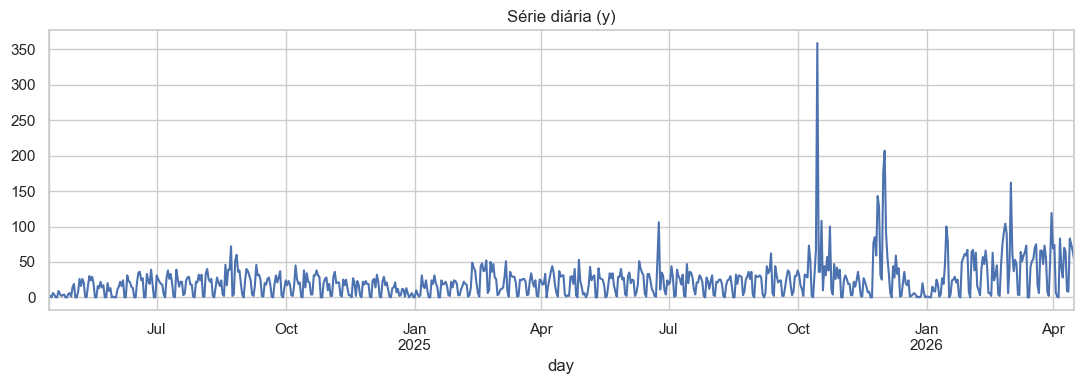

In [2]:
cache_csv = ROOT / "data" / "cache" / "series_daily.csv"

try:
    settings = load_settings()
    raw = fetch_daily_counts(settings)
    if raw.empty:
        raise ValueError("ClickHouse devolveu série vazia")
    daily = complete_daily_calendar(raw)
    print("Fonte: ClickHouse")
except Exception as e:
    print("ClickHouse indisponível ou erro:", e)
    if not cache_csv.exists():
        raise FileNotFoundError(
            f"Coloque .env válido ou gere {cache_csv} com: python scripts/run_forecast.py"
        )
    daily = pd.read_csv(cache_csv, parse_dates=["day"])
    print("Fonte:", cache_csv)

series = daily.set_index("day")["y"].sort_index().asfreq("D")
series.name = "y"
print(series.describe())
series.plot(title="Série diária (y)")
plt.tight_layout()
plt.show()

## 2. Partição treino / teste (janela final reservada para comparação)

In [3]:
TEST_HORIZON = min(28, max(7, len(series) // 5))
train = series.iloc[:-TEST_HORIZON].copy()
test = series.iloc[-TEST_HORIZON:].copy()

print(f"Treino: {len(train)} dias | Teste: {len(test)} dias")
print(f"Teste: {test.index.min().date()} → {test.index.max().date()}")

Treino: 704 dias | Teste: 28 dias
Teste: 2026-03-20 → 2026-04-16


## 3. Ajustar modelos e prever o período de teste

In [4]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX


def mae_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = float(np.mean(np.abs(y_true - y_pred)))
    r = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return m, r


def align_index(idx: pd.DatetimeIndex, values: np.ndarray) -> pd.Series:
    return pd.Series(values, index=idx[: len(values)], name="yhat")


predictions: dict[str, pd.Series] = {}
errors: dict[str, str] = {}
h = len(test)

# --- ARIMA ---
try:
    m_ar = ARIMA(train, order=(1, 1, 1)).fit()
    predictions["ARIMA(1,1,1)"] = align_index(test.index, m_ar.forecast(steps=h).to_numpy())
except Exception as e:
    errors["ARIMA(1,1,1)"] = str(e)

# --- SARIMA (semanal) ---
try:
    if len(train) >= 21:
        m_sar = SARIMAX(
            train,
            order=(1, 1, 1),
            seasonal_order=(1, 0, 1, 7),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        predictions["SARIMA(1,1,1)(1,0,1,7)"] = align_index(
            test.index, m_sar.forecast(steps=h).to_numpy()
        )
    else:
        errors["SARIMA"] = "série de treino curta demais para sazonalidade 7"
except Exception as e:
    errors["SARIMA"] = str(e)

# --- Holt–Winters / suavização exponencial ---
try:
    if len(train) >= 21:
        m_hw = ExponentialSmoothing(
            train,
            trend="add",
            seasonal="add",
            seasonal_periods=7,
            initialization_method="estimated",
        ).fit(optimized=True)
        predictions["Holt–Winters (s=7)"] = align_index(test.index, m_hw.forecast(h).to_numpy())
    else:
        m_es = ExponentialSmoothing(train, trend="add", seasonal=None).fit(optimized=True)
        predictions["Exp. smoothing (tendência)"] = align_index(test.index, m_es.forecast(h).to_numpy())
except Exception as e:
    errors["ExponentialSmoothing"] = str(e)

# --- Prophet ---
try:
    from prophet import Prophet

    ds = pd.to_datetime(train.index)
    if getattr(ds, "tz", None) is not None:
        ds = ds.tz_convert("UTC").tz_localize(None)
    df_tr = pd.DataFrame({"ds": ds, "y": train.values})
    m_pr = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
    m_pr.fit(df_tr)
    fut = m_pr.make_future_dataframe(periods=h, freq="D", include_history=False)
    fc = m_pr.predict(fut)
    fc["ds"] = pd.to_datetime(fc["ds"]).dt.normalize()
    yhat_s = fc.set_index("ds")["yhat"]
    tidx = pd.to_datetime(test.index).normalize()
    yhat = yhat_s.reindex(tidx).interpolate().bfill().ffill().to_numpy()
    predictions["Prophet"] = pd.Series(yhat[:h], index=test.index, name="yhat")
except Exception as e:
    errors["Prophet"] = str(e)

# --- XGBoost (lags + recursivo no teste) ---
try:
    import xgboost as xgb

    NLAGS = min(14, max(3, len(train) // 10))

    def build_supervised(y: np.ndarray, nlags: int) -> tuple[np.ndarray, np.ndarray]:
        X, Y = [], []
        for i in range(nlags, len(y)):
            X.append(y[i - nlags : i])
            Y.append(y[i])
        return np.asarray(X), np.asarray(Y)

    hist = list(train.astype(float).values)
    tr_y = np.asarray(hist, dtype=float)
    X_tr, y_tr = build_supervised(tr_y, NLAGS)
    if len(y_tr) < 10:
        raise ValueError("poucos pontos para XGBoost")
    xgb_m = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        verbosity=0,
    )
    xgb_m.fit(X_tr, y_tr)
    preds = []
    for _ in range(h):
        x_row = np.asarray(hist[-NLAGS:], dtype=float).reshape(1, -1)
        p = float(xgb_m.predict(x_row)[0])
        p = max(0.0, p)
        preds.append(p)
        hist.append(p)
    predictions["XGBoost (lags recursivos)"] = align_index(test.index, np.asarray(preds))
except Exception as e:
    errors["XGBoost"] = str(e)

print("Modelos com previsão:", list(predictions.keys()))
if errors:
    print("Avisos / modelos não ajustados:")
    for k, v in errors.items():
        print(f"  - {k}: {v}")

Importing plotly failed. Interactive plots will not work.
17:10:00 - cmdstanpy - INFO - Chain [1] start processing
17:10:00 - cmdstanpy - INFO - Chain [1] done processing


Modelos com previsão: ['ARIMA(1,1,1)', 'SARIMA(1,1,1)(1,0,1,7)', 'Holt–Winters (s=7)', 'Prophet', 'XGBoost (lags recursivos)']


## 4. Métricas no conjunto de teste (MAE, RMSE)

In [5]:
rows = []
for name, yhat in predictions.items():
    yhat = yhat.reindex(test.index)
    m, r = mae_rmse(test.values, yhat.values)
    rows.append({"modelo": name, "MAE": m, "RMSE": r})

metrics = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
metrics

,modelo,MAE,RMSE
0,"SARIMA(1,1,1)(1,0,1,7)",15.780416,20.112080
1,Holt–Winters (s=7),19.516914,23.131759
2,Prophet,20.199638,24.188872
3,XGBoost (lags recursivos),22.047110,28.474482
4,"ARIMA(1,1,1)",29.450428,32.675885


## 5. Gráficos: série real *vs.* cada modelo (período de teste)

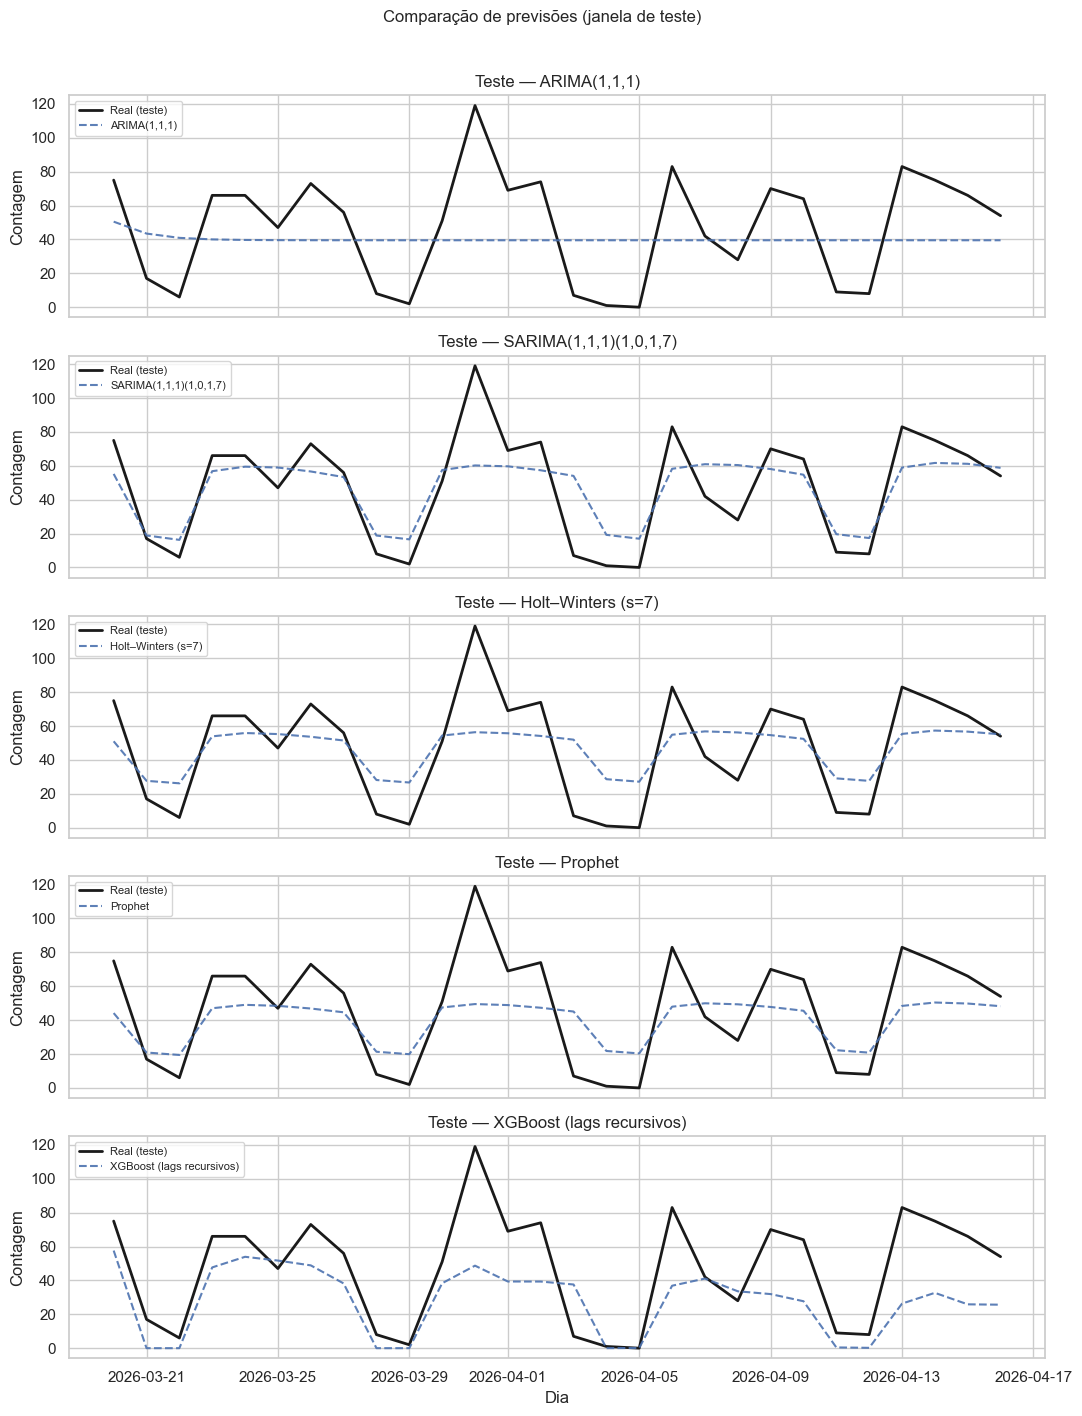

In [6]:
n_models = len(predictions)
if n_models == 0:
    raise RuntimeError("Nenhum modelo produziu previsão.")

fig, axes = plt.subplots(n_models, 1, figsize=(11, 2.8 * n_models), sharex=True)
if n_models == 1:
    axes = [axes]

for ax, (name, yhat) in zip(axes, predictions.items()):
    yhat = yhat.reindex(test.index)
    ax.plot(test.index, test.values, "k-", label="Real (teste)", linewidth=2)
    ax.plot(yhat.index, yhat.values, "--", label=name, alpha=0.9)
    ax.set_ylabel("Contagem")
    ax.legend(loc="upper left", fontsize=8)
    ax.set_title(f"Teste — {name}")

axes[-1].set_xlabel("Dia")
plt.suptitle("Comparação de previsões (janela de teste)", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 6. Gráfico de barras das métricas e sobreposição de todas as curvas

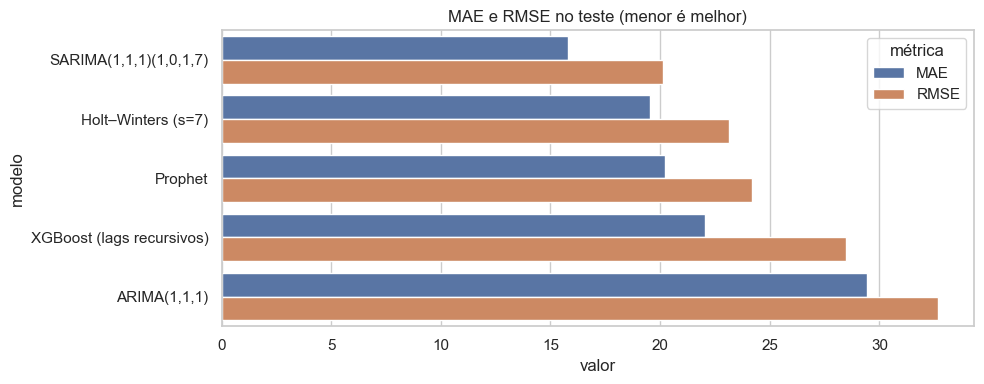

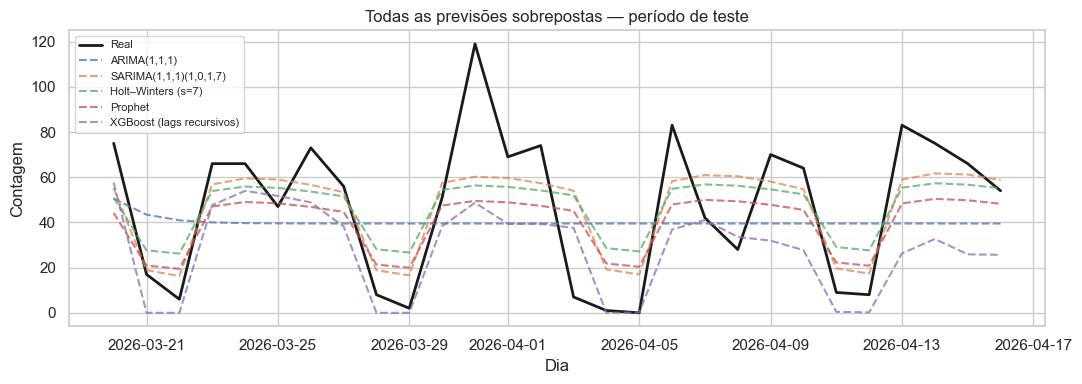

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
metrics_melt = metrics.melt(id_vars="modelo", var_name="métrica", value_name="valor")
sns.barplot(data=metrics_melt, x="valor", y="modelo", hue="métrica", ax=ax)
ax.set_title("MAE e RMSE no teste (menor é melhor)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test.index, test.values, "k-", label="Real", linewidth=2)
for name, yhat in predictions.items():
    ax.plot(yhat.index, yhat.reindex(test.index).values, "--", alpha=0.75, label=name)
ax.set_title("Todas as previsões sobrepostas — período de teste")
ax.legend(loc="best", fontsize=8)
ax.set_xlabel("Dia")
ax.set_ylabel("Contagem")
plt.tight_layout()
plt.show()

## 7. (Opcional) Resíduos no teste

Resíduo = valor real − previsto. Ajuda a detetar sub/sobre-previsão sistemática.

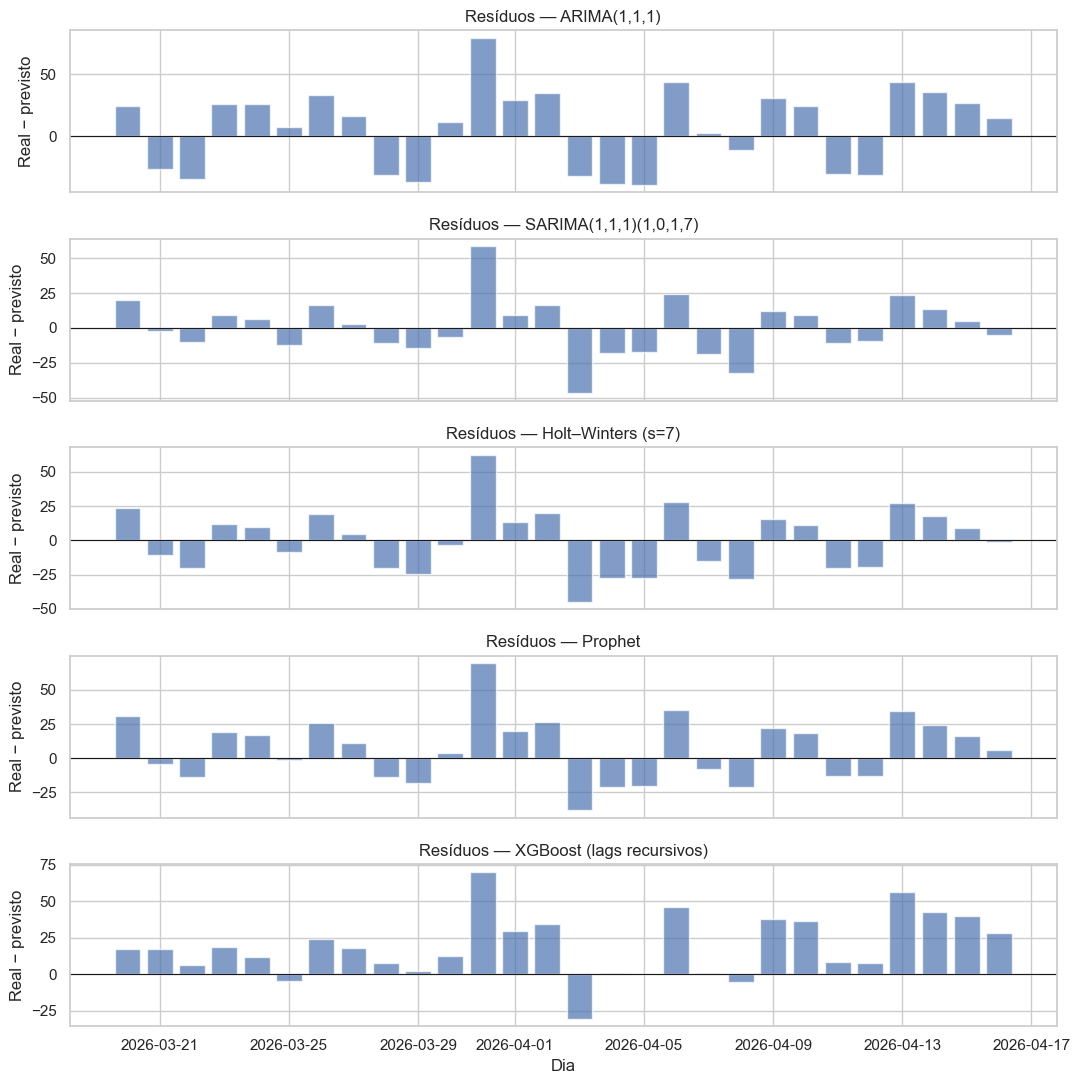

In [8]:
n_models = len(predictions)
fig, axes = plt.subplots(n_models, 1, figsize=(11, 2.2 * n_models), sharex=True)
if n_models == 1:
    axes = [axes]

for ax, (name, yhat) in zip(axes, predictions.items()):
    resid = test - yhat.reindex(test.index)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.bar(resid.index, resid.values, width=0.8, alpha=0.7)
    ax.set_ylabel("Real − previsto")
    ax.set_title(f"Resíduos — {name}")

axes[-1].set_xlabel("Dia")
plt.tight_layout()
plt.show()